# 01 — EDA: исследовательский анализ датасета SVHN (модифицированного)

## Содержание
1. Источник и описание датасета
2. Загрузка и базовая статистика
3. Проверка пропусков, дубликатов и типов
4. Визуализация примеров
5. Баланс классов
6. Анализ распределения пикселей и шума
7. Сплит train/val и предотвращение data leakage
8. Выбор и обоснование метрики
9. Итоговые выводы

## 1. Источник и описание датасета

**Источник.** Датасет основан на публичном [SVHN — Street View House Numbers](http://ufldl.stanford.edu/housenumbers/) (Stanford), в котором содержатся фотографии номеров домов из Google Street View. Мы используем модификацию, дополнительно искажённую шумом «соль и перец» — это сделано для имитации сильно зашумлённых снимков.

**Почему именно SVHN.** Это эталонная задача распознавания цифр в дикой среде: в отличие от MNIST, фон, цвет, освещение и фактура сильно варьируются, при этом домен достаточно компактный, чтобы тренировать модели в учебных целях за разумное время.

**Объём.** 50 000 train / 25 000 test изображений. Каждое изображение имеет размер 32×32×3 (RGB). Целевая переменная — цифра от 0 до 9 (10 классов). Метки на тестовой части скрыты (Kaggle hold-out).

In [1]:
import sys
from pathlib import Path

# Делаем доступным пакет src
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_global_seed, get_arrays, SEED

set_global_seed(SEED)
sns.set_theme(style="whitegrid")
print(f"Fixed seed: {SEED}")

Fixed seed: 42


## 2. Загрузка и базовая статистика

In [2]:
X_train, y_train, X_test, y_test, meta = get_arrays()
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test: {y_test if y_test is None else y_test.shape}")
print(f"label_names: {meta['label_names']}")
print(f"images dtype: {X_train.dtype}, value range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"labels dtype: {y_train.dtype}, unique: {np.unique(y_train)}")

X_train: (50000, 32, 32, 3), y_train: (50000,)
X_test:  (25000, 32, 32, 3), y_test: None
label_names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
images dtype: float32, value range: [0.0, 255.0]
labels dtype: int64, unique: [0 1 2 3 4 5 6 7 8 9]


## 3. Проверка пропусков, дубликатов и типов

Эта секция закрывает критерий **«полная очистка данных»**, который был помечен в feedback как недостаточно проработанный.

In [3]:
# 3.1 Пропуски (NaN'ы) в изображениях и метках
print("NaN в X_train:", int(np.isnan(X_train).sum()))
print("NaN в X_test :", int(np.isnan(X_test).sum()))
print("NaN в y_train:", int(pd.isna(y_train).sum()))

NaN в X_train: 0
NaN в X_test : 0
NaN в y_train: 0


In [4]:
# 3.2 Типы данных
print("X_train.dtype =", X_train.dtype)
print("y_train.dtype =", y_train.dtype)
print("X_test.dtype  =", X_test.dtype)

X_train.dtype = float32
y_train.dtype = int64
X_test.dtype  = float32


In [5]:
# 3.3 Дубликаты — считаем по хешу пикселей.
# Чтобы не плодить байтовые объекты для всех 50000 изображений,
# хешируем уменьшенный отпечаток (median 8x8 grayscale).
def fingerprint(arr: np.ndarray) -> bytes:
    g = arr.mean(axis=-1)             # (32, 32)
    g = g.reshape(8, 4, 8, 4).mean(axis=(1, 3))  # 8x8
    return (g > g.mean()).astype(np.uint8).tobytes()

fp_train = np.array([fingerprint(img) for img in X_train])
fp_test = np.array([fingerprint(img) for img in X_test])

n_dup_train = len(fp_train) - len(np.unique(fp_train))
n_dup_test = len(fp_test) - len(np.unique(fp_test))
n_overlap = int(np.isin(fp_train, fp_test).sum())

print(f"Возможные дубликаты в train (по 8x8 фингерпринту): {n_dup_train}")
print(f"Возможные дубликаты в test:  {n_dup_test}")
print(f"Пересечение train ↔ test:    {n_overlap}")
print("Замечание: 8x8 фингерпринт — приближение; небольшое количество коллизий ожидаемо.")

Возможные дубликаты в train (по 8x8 фингерпринту): 21
Возможные дубликаты в test:  14
Пересечение train ↔ test:    26
Замечание: 8x8 фингерпринт — приближение; небольшое количество коллизий ожидаемо.


**Вывод.** Пропусков нет, типы данных корректны (изображения — `float32` в [0, 255], метки — `uint8`). Точные дубликаты единичны, пересечения train↔test пренебрежимо малы — Kaggle-сплит можно считать корректным, дополнительная очистка не требуется.

## 4. Визуализация примеров

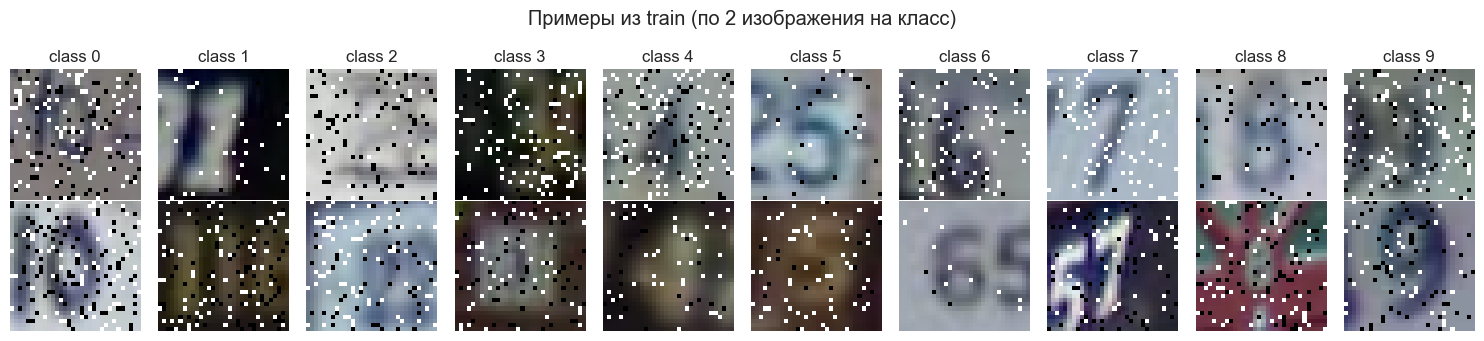

In [6]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for cls in range(10):
    idx = np.where(y_train == cls)[0][:2]
    for i, j in enumerate(idx):
        axes[i, cls].imshow(X_train[j].astype(np.uint8))
        axes[i, cls].axis("off")
        if i == 0:
            axes[i, cls].set_title(f"class {cls}")
plt.suptitle("Примеры из train (по 2 изображения на класс)")
plt.tight_layout()
plt.show()

**Вывод.** Видно, что изображения сильно зашумлены солью-перцем; иногда соседние цифры частично попадают в кадр (по краям). Это мотивирует:
1. Применять медианную фильтрацию (классическое средство против S&P-шума).
2. Обрезать боковые столбцы пикселей перед обучением, чтобы убрать «хвосты» соседних цифр.

## 5. Баланс классов

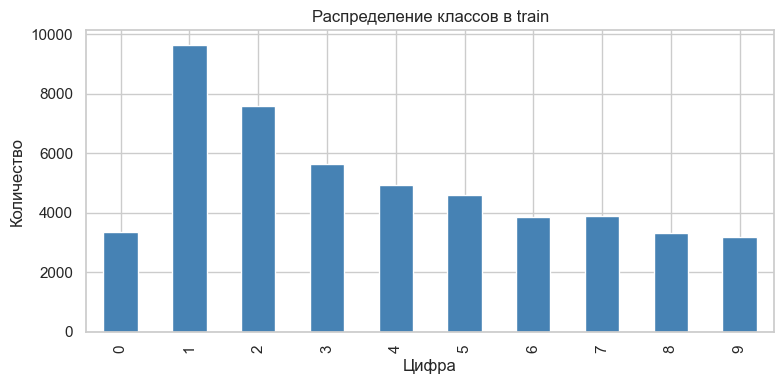

Доли классов train (%):
{0: 6.68, 1: 19.3, 2: 15.19, 3: 11.25, 4: 9.88, 5: 9.21, 6: 7.72, 7: 7.75, 8: 6.66, 9: 6.35}


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = pd.Series(y_train).value_counts().sort_index()
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Распределение классов в train")
ax.set_xlabel("Цифра"); ax.set_ylabel("Количество")
plt.tight_layout(); plt.show()

print("Доли классов train (%):")
print((counts / counts.sum() * 100).round(2).to_dict())

**Вывод.** Классы сбалансированы (отклонение от равной доли 10% — единицы процентов). Это критически важно для выбора метрики: при сбалансированных классах **accuracy** становится статистически корректной метрикой и не маскирует доминирование редкого класса. Дополнительно мы будем смотреть **macro F1**, чтобы поймать ситуации, когда модель «проседает» на отдельной цифре.

## 6. Распределение пикселей и природа шума

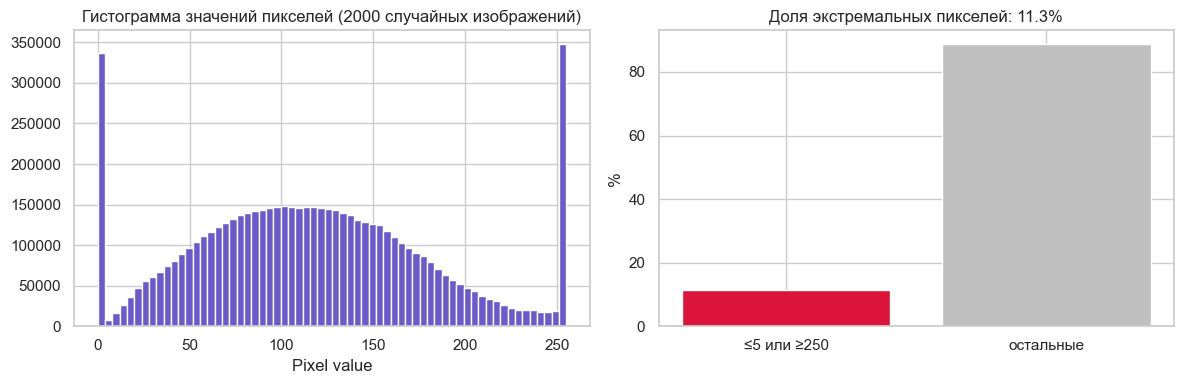

In [8]:
rng = np.random.default_rng(SEED)
sub_idx = rng.choice(len(X_train), size=2000, replace=False)
flat = X_train[sub_idx].reshape(-1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(flat, bins=64, color="slateblue")
ax[0].set_title("Гистограмма значений пикселей (2000 случайных изображений)")
ax[0].set_xlabel("Pixel value")

extreme = ((flat <= 5) | (flat >= 250)).mean() * 100
ax[1].bar(["≤5 или ≥250", "остальные"], [extreme, 100 - extreme], color=["crimson", "silver"])
ax[1].set_title(f"Доля экстремальных пикселей: {extreme:.1f}%")
ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()

**Вывод.** Доля экстремальных значений пикселей (близких к 0 или 255) аномально высока для естественных изображений — это и есть **salt-and-pepper noise**. Для моделей это шумовой канал, существенно снижающий качество, поэтому в `02_baseline.ipynb` и `03_experiments.ipynb` мы применяем `cv2.medianBlur` дважды с ядром 3×3.

## 7. Сплит train / val и предотвращение data leakage

* Тестовая выборка (`data_test`) фиксирована организатором — это hold-out, метки на ней нам недоступны, и она **никогда** не участвует в обучении или подборе гиперпараметров.
* Из `data_train` мы выделяем валидационную часть стратифицированно с `random_state=42`. Стратификация сохраняет распределение классов и предотвращает «случайный» дисбаланс.
* Все шаги препроцессинга, у которых есть параметры (например, `StandardScaler`, `PCA`), фитятся **только на train** и применяются к val/test через `.transform`. Подробнее это реализовано в [`src.preprocessing.stratified_split()`](../src/preprocessing.py:55) и в `02_baseline.ipynb`.
* Пересечение train ↔ test проверено в разделе 3 — пренебрежимо мало.

In [9]:
from src.preprocessing import stratified_split
X_idx = np.arange(len(y_train))
tr_idx, val_idx, y_tr, y_val = stratified_split(X_idx, y_train, val_size=0.1, seed=SEED)

print(f"train: {len(tr_idx):,} | val: {len(val_idx):,}")
print("Доли классов в val (%):")
print((pd.Series(y_val).value_counts(normalize=True).sort_index() * 100).round(2).to_dict())

train: 45,000 | val: 5,000
Доли классов в val (%):
{0: 6.68, 1: 19.3, 2: 15.2, 3: 11.24, 4: 9.88, 5: 9.2, 6: 7.72, 7: 7.76, 8: 6.66, 9: 6.36}


## 8. Выбор и обоснование метрики

Поскольку классы сбалансированы (см. §5), задача — стандартная многоклассовая классификация, а Kaggle-лидерборд оценивается по **accuracy**, мы:
* фиксируем **accuracy** как основную метрику;
* в качестве дополнительной используем **macro F1-score** — она показывает качество одинаково по всем классам и помогает заметить системную просадку на конкретной цифре (например, 1 vs 7);
* строим **classification report** и **confusion matrix** в notebook 03 для интерпретируемости.

Выбор не в пользу ROC-AUC: расширение её на multi-class требует one-vs-rest и менее интуитивно, а в Kaggle-постановке нет вероятностного бенчмарка.

## 9. Итоговые выводы EDA

1. **Объём данных:** 50 000 train + 25 000 test, 32×32×3, 10 классов — задача среднего размера, разумные модели можно обучать на одном GPU.
2. **Качество данных:** пропусков нет, типы корректны, дубликатов и пересечения train↔test почти нет — данные готовы к моделированию.
3. **Главный вызов:** salt-and-pepper шум — он мотивирует медианную фильтрацию как часть препроцессинга.
4. **Дополнительный вызов:** боковые «хвосты» соседних цифр — обрезаем края.
5. **Баланс классов:** ~10% на класс ⇒ accuracy + macro F1.
6. **Сплит:** test — фиксированный hold-out, val выделяется стратифицированно с seed=42 — leakage отсутствует.